# Image-Based Cancer Diagnosis Using a Convolutional Neural Network

## Objective

The goal of this assignment is to build a Convolutional Neural Network that can classify breast ultrasound images as either benign or malignant. The first stage is building an image data pipeline that loads the images, resizes them to a fixed resolution, applies augmentation, normalizes the pixel values using the dataset mean and standard deviation, and splits the data into training, validation, and test sets while keeping the class balance.

In [1]:
# Importing PyTorch and the tools needed for the data pipeline and CNN
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Standard libraries for file handling, numbers, and images
import os
import glob
import numpy as np
from PIL import Image

# For the stratified data split
from sklearn.model_selection import train_test_split

# For plotting in Phase C
import matplotlib.pyplot as plt

# Using the GPU if one is available, otherwise the CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Downloading the Dataset

I used the Breast Ultrasound Images (BUSI) dataset. It contains three folders: benign, malignant, and normal. Since this is a binary classification task, I used only the benign and malignant images. The dataset also includes segmentation mask images, which are not used for classification.

In [2]:
# Installing kaggle and setting up the new-style API token
!pip install kaggle -q

import os
os.environ['KAGGLE_API_TOKEN'] = "KGAT_5e4ab9b918a21957e6ac5d80ad091d88"

# Downloading and unzipping the BUSI dataset
!kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset
!unzip -q breast-ultrasound-images-dataset.zip -d busi_data

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
100% 195M/195M [00:01<00:00, 152MB/s]



## Collecting Image Paths and Labels

I collected the file paths of the benign and malignant images and gave them labels (0 for benign and 1 for malignant). I skipped every file that has "_mask" in its name, because those are segmentation masks and not the actual ultrasound images.

In [3]:
# Folder containing the benign / malignant / normal subfolders
# NOTE: check this path after unzipping and change it if the structure is different
data_root = "busi_data/Dataset_BUSI_with_GT"

# Using benign and malignant only, for binary classification
class_to_label = {"benign": 0, "malignant": 1}

image_paths = []
labels = []

for class_name, label in class_to_label.items():
    folder = os.path.join(data_root, class_name)
    for path in glob.glob(os.path.join(folder, "*.png")):
        # Skipping the mask images and keeping only the real ultrasound images
        if "_mask" in os.path.basename(path):
            continue
        image_paths.append(path)
        labels.append(label)

labels = np.array(labels)
print("Total images:", len(image_paths))
print("Benign:", (labels == 0).sum(), "| Malignant:", (labels == 1).sum())

Total images: 647
Benign: 437 | Malignant: 210


## Splitting into Training, Validation, and Test Sets

I split the data into 70% training, 15% validation, and 15% testing, as required. I used stratified splitting so that the ratio of benign to malignant images stays the same across all three sets. The split is done in two steps: first the training set is separated, and then the remaining part is divided equally into validation and test.

In [4]:
# First split: 70% training and 30% temporary (used for validation + test)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels, test_size=0.30, random_state=42, stratify=labels
)

# Second split: divide the 30% equally into 15% validation and 15% test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, random_state=42, stratify=temp_labels
)

print("Training images:  ", len(train_paths))
print("Validation images:", len(val_paths))
print("Testing images:   ", len(test_paths))

Training images:   452
Validation images: 97
Testing images:    98


## Custom Dataset Class

I created a custom Dataset class so that PyTorch can load the images one at a time. It opens each image, converts it to RGB, applies the transformations, and returns the image tensor together with its label. The label is returned as a float because the model uses a sigmoid output with Binary Cross-Entropy loss.

In [5]:
class BreastUltrasoundDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        # Total number of images
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Opening the image and making sure it has 3 channels (RGB)
        image = Image.open(self.image_paths[idx]).convert("RGB")

        # Applying the transformations
        if self.transform:
            image = self.transform(image)

        # Label returned as a float tensor for BCELoss
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return image, label

## Calculating the Dataset Mean and Standard Deviation

The assignment requires normalizing the pixel values using the dataset mean and standard deviation. I calculated these values from the training images only, so that no information from the validation or test images is used. These values are then applied in the normalization step.

In [6]:
# A basic transform (resize + to tensor) used only to compute mean and std
basic_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Temporary dataset and loader over the training images
stats_dataset = BreastUltrasoundDataset(train_paths, train_labels, transform=basic_transform)
stats_loader = DataLoader(stats_dataset, batch_size=32, shuffle=False)

# Computing the per-channel mean and standard deviation
mean = torch.zeros(3)
std = torch.zeros(3)
total_images = 0

for images, _ in stats_loader:
    batch = images.size(0)
    images = images.view(batch, 3, -1)   # flatten height and width
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total_images += batch

mean /= total_images
std /= total_images

print("Dataset mean:", mean)
print("Dataset std: ", std)

Dataset mean: tensor([0.3270, 0.3270, 0.3270])
Dataset std:  tensor([0.1975, 0.1975, 0.1975])


## Transformations and Data Augmentation

For the training set I applied augmentation (random horizontal and vertical flips and small rotations) to help reduce overfitting. The validation and test sets are only resized and normalized, with no augmentation, so that they stay fixed during evaluation. All images are resized to 128x128, converted to tensors, and normalized using the mean and standard deviation calculated above.

In [7]:
# Training transform: resize, augment, convert to tensor, normalize
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Validation/Test transform: resize, convert, normalize (no augmentation)
eval_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [8]:
# Creating the datasets for each split with the correct transform
train_dataset = BreastUltrasoundDataset(train_paths, train_labels, transform=train_transform)
val_dataset   = BreastUltrasoundDataset(val_paths, val_labels, transform=eval_transform)
test_dataset  = BreastUltrasoundDataset(test_paths, test_labels, transform=eval_transform)

# Creating the data loaders that feed batches of images to the model
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Checking that one batch has the expected shape
images, batch_labels = next(iter(train_loader))
print("One batch of images:", images.shape)   # expected: [32, 3, 128, 128]
print("One batch of labels:", batch_labels.shape)

One batch of images: torch.Size([32, 3, 128, 128])
One batch of labels: torch.Size([32])


## Building the CNN Architecture

I designed a custom Convolutional Neural Network from scratch. It has three convolutional blocks for feature extraction, where each block has a convolutional layer, batch normalization, a ReLU activation, and a max-pooling layer that halves the image size. After the three blocks, the feature maps are flattened and passed through a fully connected hidden layer with a dropout layer for regularization, and finally to a single output node with a sigmoid activation for binary classification.

In [9]:
class CancerCNN(nn.Module):
    def __init__(self):
        super(CancerCNN, self).__init__()

        # ---- Feature extraction: three convolutional blocks ----
        # Block 1: 3 input channels -> 32 feature maps
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Block 2: 32 -> 64 feature maps
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Block 3: 64 -> 128 feature maps
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Activation and pooling used in every block
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)   # halves the height and width

        # ---- Classification head ----
        # After 3 poolings, a 128x128 image becomes 16x16 with 128 channels
        # So the flattened size is 128 * 16 * 16 = 32768
        self.fc1 = nn.Linear(128 * 16 * 16, 128)
        self.dropout = nn.Dropout(0.5)          # regularization
        self.fc2 = nn.Linear(128, 1)            # single output node
        self.sigmoid = nn.Sigmoid()             # for binary classification

    def forward(self, x):
        # Passing through the three convolutional blocks
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))

        # Flattening the feature maps into a single vector per image
        x = x.view(x.size(0), -1)

        # Passing through the fully connected layers
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc2(x))
        return x

# Creating the model and moving it to the GPU/CPU
model = CancerCNN().to(device)
print(model)

CancerCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32768, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


## Loss Function and Optimizer

I used Binary Cross-Entropy loss (BCELoss), which is the correct loss for a binary classification problem with a sigmoid output. For the optimizer I used Adam with a learning rate of 0.001, since it usually converges well without much manual tuning.

In [10]:
# Binary Cross-Entropy loss for the sigmoid output
criterion = nn.BCELoss()

# Adam optimizer with a learning rate of 0.001
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Training the Model

I trained the model for 25 epochs. In each epoch I trained on the training set and then checked performance on the validation set. I recorded the training and validation loss and accuracy for every epoch so that I can plot the learning curves later to check for overfitting.

In [11]:
# Number of training epochs (the assignment requires at least 20)
num_epochs = 25

# Lists to store the metrics from each epoch for plotting later
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):

    # ---------- Training phase ----------
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, batch_labels in train_loader:
        images = images.to(device)
        batch_labels = batch_labels.to(device).unsqueeze(1)   # shape [batch, 1]

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, batch_labels)

        # Backward pass and weight update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Tracking loss and accuracy
        running_loss += loss.item() * images.size(0)
        predicted = (outputs >= 0.5).float()
        correct += (predicted == batch_labels).sum().item()
        total += batch_labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # ---------- Validation phase ----------
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():   # no gradient needed during validation
        for images, batch_labels in val_loader:
            images = images.to(device)
            batch_labels = batch_labels.to(device).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, batch_labels)

            val_running_loss += loss.item() * images.size(0)
            predicted = (outputs >= 0.5).float()
            val_correct += (predicted == batch_labels).sum().item()
            val_total += batch_labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total

    # Saving the results of this epoch
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Printing the progress for this epoch
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

print("\nTraining finished.")

Epoch [1/25] Train Loss: 3.9840, Train Acc: 0.6350 | Val Loss: 1.4821, Val Acc: 0.6495
Epoch [2/25] Train Loss: 0.9319, Train Acc: 0.6770 | Val Loss: 0.6910, Val Acc: 0.4845
Epoch [3/25] Train Loss: 0.5521, Train Acc: 0.7279 | Val Loss: 0.6115, Val Acc: 0.6701
Epoch [4/25] Train Loss: 0.5253, Train Acc: 0.7456 | Val Loss: 0.5676, Val Acc: 0.7629
Epoch [5/25] Train Loss: 0.5191, Train Acc: 0.7677 | Val Loss: 0.5707, Val Acc: 0.7320
Epoch [6/25] Train Loss: 0.4985, Train Acc: 0.7920 | Val Loss: 0.5596, Val Acc: 0.7113
Epoch [7/25] Train Loss: 0.4846, Train Acc: 0.8186 | Val Loss: 0.5486, Val Acc: 0.7216
Epoch [8/25] Train Loss: 0.4611, Train Acc: 0.8053 | Val Loss: 0.5091, Val Acc: 0.7629
Epoch [9/25] Train Loss: 0.4807, Train Acc: 0.7699 | Val Loss: 0.5550, Val Acc: 0.7216
Epoch [10/25] Train Loss: 0.4617, Train Acc: 0.8075 | Val Loss: 0.6191, Val Acc: 0.6495
Epoch [11/25] Train Loss: 0.4379, Train Acc: 0.7942 | Val Loss: 0.5340, Val Acc: 0.7835
Epoch [12/25] Train Loss: 0.4520, Train A

## Learning Curves

These plots show the training and validation loss and accuracy across all epochs. They help to check whether the model is overfitting or underfitting. If the training accuracy keeps improving while the validation accuracy stops improving or gets worse, it is a sign of overfitting.

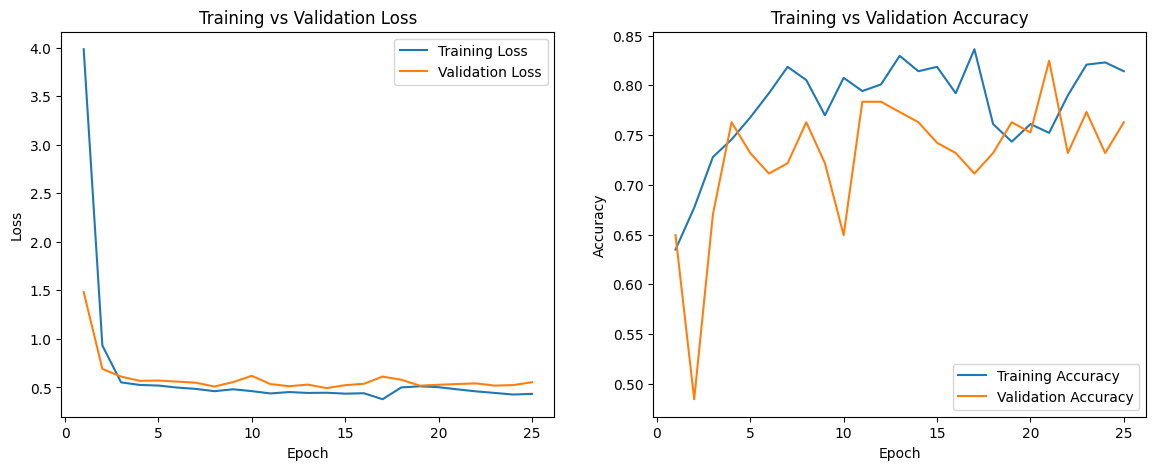

In [12]:
# Plotting the learning curves side by side
epochs_range = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: training vs validation loss
axes[0].plot(epochs_range, train_losses, label="Training Loss")
axes[0].plot(epochs_range, val_losses, label="Validation Loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Right plot: training vs validation accuracy
axes[1].plot(epochs_range, train_accuracies, label="Training Accuracy")
axes[1].plot(epochs_range, val_accuracies, label="Validation Accuracy")
axes[1].set_title("Training vs Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.savefig("learning_curves.png", dpi=100, bbox_inches='tight')
plt.show()

## Getting Predictions on the Test Set

Before plotting the ROC curve and confusion matrix, I ran the trained model on the test set. I collected the true labels, the predicted probabilities from the sigmoid output, and the predicted classes (using 0.5 as the threshold). The test set was not used during training, so this gives a fair measure of how well the model performs on unseen images.

In [13]:
# Collecting predictions on the test set
model.eval()

y_true = []
y_prob = []

with torch.no_grad():
    for images, batch_labels in test_loader:
        images = images.to(device)
        outputs = model(images)   # sigmoid probabilities

        # Storing the true labels and the predicted probabilities
        y_true.extend(batch_labels.numpy())
        y_prob.extend(outputs.cpu().numpy().flatten())

y_true = np.array(y_true)
y_prob = np.array(y_prob)

# Converting probabilities into class predictions using a 0.5 threshold
y_pred = (y_prob >= 0.5).astype(int)

print("Number of test images:", len(y_true))

Number of test images: 98


## ROC Curve

The ROC curve shows the trade-off between the true positive rate and the false positive rate at different thresholds. The area under the curve (AUC) is a single number that summarizes how well the model separates the two classes. An AUC closer to 1 means better performance.

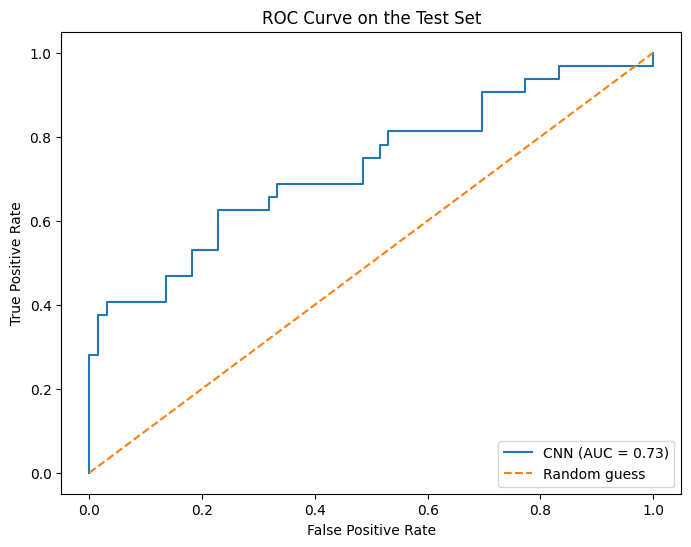

In [14]:
from sklearn.metrics import roc_curve, auc

# Calculating the ROC curve and the AUC score on the test set
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"CNN (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random guess")
plt.title("ROC Curve on the Test Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

plt.savefig("roc_curve.png", dpi=100, bbox_inches='tight')
plt.show()

## Confusion Matrix

The confusion matrix shows how many test images were classified correctly and incorrectly for each class. The diagonal values are the correct predictions, and the off-diagonal values are the errors. In this cancer diagnosis task, a false negative (a malignant image predicted as benign) is the most serious type of error.

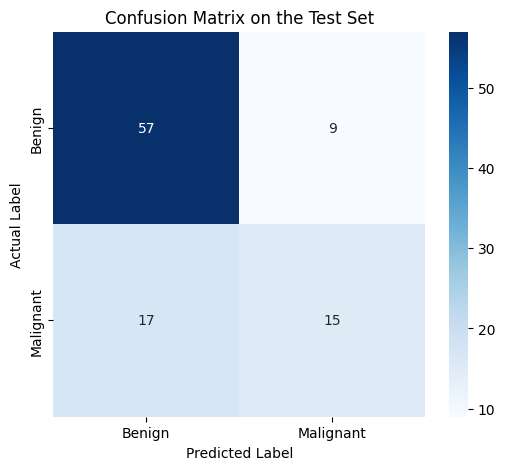

In [15]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Building the confusion matrix from the test predictions
cm = confusion_matrix(y_true, y_pred)

# Drawing it as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)
plt.title("Confusion Matrix on the Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.savefig("confusion_matrix.png", dpi=100, bbox_inches='tight')
plt.show()

## Conclusion

In this assignment I built a Convolutional Neural Network from scratch to classify breast ultrasound images as benign or malignant. I first created an image pipeline that resized the images, applied augmentation, normalized them using the dataset mean and standard deviation, and split the data into stratified training, validation, and test sets. The CNN used three convolutional blocks with batch normalization and max pooling for feature extraction, followed by a fully connected layer with dropout and a sigmoid output for binary classification.

The model was trained for 25 epochs using Binary Cross-Entropy loss and the Adam optimizer, while tracking the training and validation performance each epoch. I then evaluated the model using learning curves, an ROC curve with the AUC score, and a confusion matrix on the unseen test set. These plots show how well the model learned and how it performed on new images. Overall, this project helped me understand the full deep learning workflow for medical image classification, from data preparation to model evaluation.